# fMRI Reliability Pipeline
- Designed to parametrically analyze fMRI files to identify which pipelines produce the most robust results.

In [73]:
import pandas as pd
import itertools

from scipy.spatial.distance import pdist
from scipy.stats import f_oneway, ttest_ind

# Plotting Packages 
import seaborn as sns
import matplotlib.pyplot as plt
import ptitprince as pt # Only needed for raincloud plot
import configFunctions as config

### Required files
- 'coordinatesAll.csv' - generated by serverFunctions, final output of mergeOutputs.sh.
- 

In [74]:
# A configuration function to make output images easier to modify for publication.
config.svg_editing()

In [75]:
# load data, inspect
df = pd.read_csv('coordinatesAll.csv')
df.head()

,filename,filepath,subject,session,task,sequence_type,target,clustRegion,clustMask,X,Y,Z
0,068.04.rest.se.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,4,rest,se,network,ldlpfc,orig,47.0,-23.0,41.0
1,068.02.rest.me.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,2,rest,me,network,ldlpfc,dilate_5,23.0,-45.0,39.0
2,068.04.rest.me.errts.targ.seed.fisher.clust.ld...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,4,rest,me,seed,ldlpfc,erode_1,39.0,-37.0,33.0
3,068.01.rest.se.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,1,rest,se,network,ldlpfc,erode_1,49.0,-23.0,33.0
4,068.03.rest.me.errts.targ.network.fisher.clust...,/cbica/projects/nbthetaconn/pipeline/results/0...,68,3,rest,me,network,ldlpfc,orig,49.0,-21.0,41.0


In [76]:
# Group by subject and condition
grouping_vars = ['subject', 'target', 'clustMask', 'sequence_type']

subjVec = df['subject'].unique()
targetVec = df['target'].unique()
cMaskVec = df['clustMask'].unique()
seqTypeVec = df['sequence_type'].unique()

# Create an array with each possible combo.
combinations = list(itertools.product(subjVec, targetVec, cMaskVec, seqTypeVec))

# Put into pandas dataframe
combodf = pd.DataFrame(combinations, columns=['subject', 'target', 'clustMask', 'sequence_type'])
combodf.head()

,subject,target,clustMask,sequence_type
0,68,network,orig,se
1,68,network,orig,me
2,68,network,dilate_5,se
3,68,network,dilate_5,me
4,68,network,erode_1,se


In [77]:
# Perform the analysis - span the set of each combination of parameters, take the mean euclidean distance across those sessions.
results = []

for combo in combinations:
    df_filt = df[
        (df['subject'] == combo[0]) & 
        (df['target'] == combo[1]) & 
        (df['clustMask'] == combo[2]) & 
        (df['sequence_type'] == combo[3])
    ]
    meanDist = round(pdist(df_filt[['X','Y','Z']], metric='euclidean').mean(),2)
    results.append(meanDist)

# Append this new column to the previously generated df.
combodf['mean_distance'] = results
combodf.head()

,subject,target,clustMask,sequence_type,mean_distance
0,68,network,orig,se,3.52
1,68,network,orig,me,3.00
2,68,network,dilate_5,se,15.76
3,68,network,dilate_5,me,27.82
4,68,network,erode_1,se,8.60


# Plotting

In [78]:
groupVars = ['target', 'clustMask', 'sequence_type']
targetName = 'sgACC'
clusterRegion = 'dlPFC'
groupVarNames = [f'{targetName} mask', f'{clusterRegion} mask', 'Sequence Type']


### Traditional Violin + Rain plot

C:\Users\aboha\AppData\Local\Temp\ipykernel_1736\1360308577.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


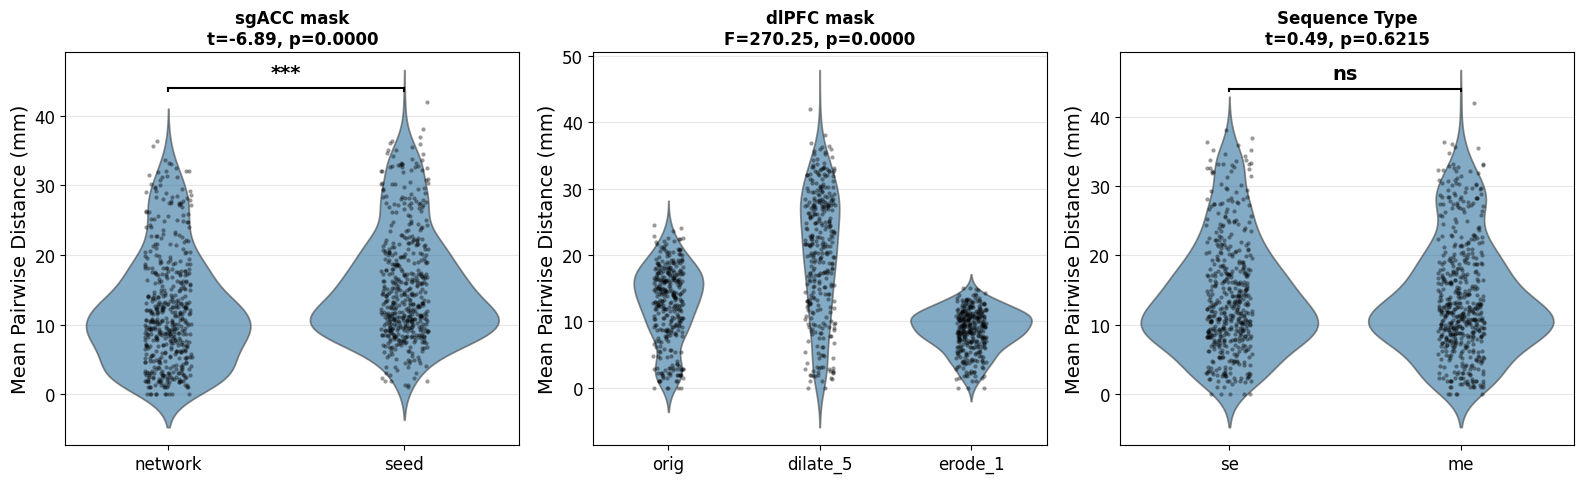

In [79]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (var, varPlot) in enumerate(zip(groupVars, groupVarNames)):
    # Violin plot
    sns.violinplot(data=combodf, x=var, y='mean_distance', ax=axes[idx], 
                   inner=None, alpha=0.6)
    
    # Overlay individual data points
    sns.stripplot(data=combodf, x=var, y='mean_distance', ax=axes[idx],
                  color='black', alpha=0.4, size=3, jitter=True)
    
    # Get unique groups
    groups = combodf[var].unique()
    group_data = [combodf[combodf[var] == val]['mean_distance'].dropna()
                  for val in groups]
    
    # Perform statistical test (t-test for 2 groups, ANOVA for more)
    if len(groups) == 2:
        stat, p_val = ttest_ind(group_data[0], group_data[1])
        stat_name = 't'
        
        # Add significance line and star
        y_max = combodf['mean_distance'].max()
        y_range = combodf['mean_distance'].max() - combodf['mean_distance'].min()
        line_height = y_max + 0.05 * y_range
        star_height = line_height + 0.02 * y_range
        
        # Draw line
        axes[idx].plot([0, 1], [line_height, line_height], 'k-', linewidth=1.5)
        axes[idx].plot([0, 0], [line_height - 0.01 * y_range, line_height], 'k-', linewidth=1.5)
        axes[idx].plot([1, 1], [line_height - 0.01 * y_range, line_height], 'k-', linewidth=1.5)
        
        # Add star based on significance
        if p_val < 0.001:
            star = '***'
        elif p_val < 0.01:
            star = '**'
        elif p_val < 0.05:
            star = '*'
        else:
            star = 'ns'
        
        axes[idx].text(0.5, star_height, star, ha='center', va='bottom', 
                      fontsize=14, fontweight='bold')
    else:
        # ANOVA for more than 2 groups
        stat, p_val = f_oneway(*group_data)
        stat_name = 'F'
    
    # Add title with statistics
    axes[idx].set_title(f'{varPlot}\n{stat_name}={stat:.2f}, p={p_val:.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Mean Pairwise Distance (mm)')
    axes[idx].tick_params(axis='x')

plt.tight_layout()
plt.savefig('violin.svg')
plt.show()

### Raincloud plot - half violin, box, and rainplot.

C:\Users\aboha\AppData\Local\Temp\ipykernel_1736\3534356984.py:66: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


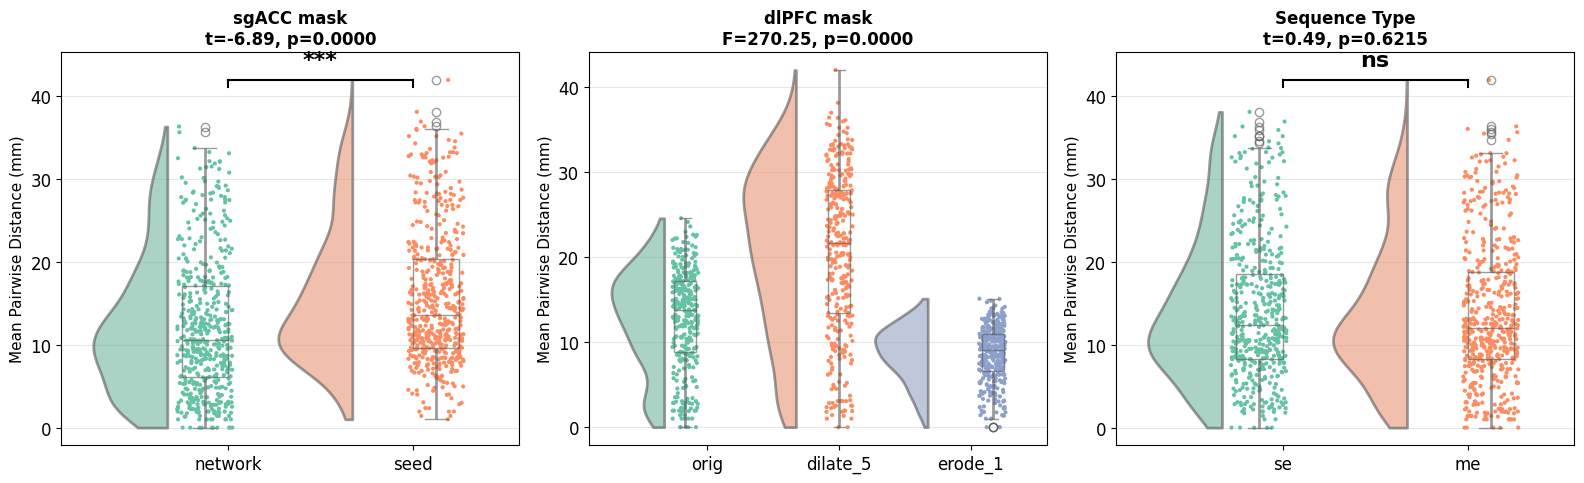

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (var, varPlot) in enumerate(zip(groupVars, groupVarNames)):
    # Create raincloud plot
    testVar = pt.RainCloud(data=combodf, x=var, y='mean_distance', ax=axes[idx], 
        palette='Set2', hue=var, bw=0.3, width_viol=0.8, width_box=0.5,
        orient='v', alpha=0.6, dodge=True, pointplot=False, point_size=3, 
        linewidth=2, jitter=0.3)
    
    # Get unique groups
    groups = combodf[var].unique()
    group_data = [combodf[combodf[var] == val]['mean_distance'].dropna()
                  for val in groups]
    
    # Open up the plot to ensure the peaks for each distribution are visible.
    percSpread = 0.4 # Defines how much you want to extend past current limits.
    xmin, xmax = axes[idx].get_xlim()
    axes[idx].set_xlim((xmin-(percSpread), xmax+(percSpread)))

    # Perform statistical test (t-test for 2 groups, ANOVA for more)
    if len(groups) == 2:
        stat, p_val = ttest_ind(group_data[0], group_data[1])
        stat_name = 't'
        
        # Add significance line and star
        y_max = combodf['mean_distance'].max()
        y_min = combodf['mean_distance'].min()
        y_range = y_max - y_min
        line_height = y_max + 0 * y_range
        star_height = line_height + 0.03 * y_range
        
        # Draw bracket line
        axes[idx].plot([0, 1], [line_height, line_height], 'k-', linewidth=1.5)
        axes[idx].plot([0, 0], [line_height - 0.02 * y_range, line_height], 'k-', linewidth=1.5)
        axes[idx].plot([1, 1], [line_height - 0.02 * y_range, line_height], 'k-', linewidth=1.5)
        
        # Add star based on significance level
        if p_val < 0.001:
            star = '***'
        elif p_val < 0.01:
            star = '**'
        elif p_val < 0.05:
            star = '*'
        else:
            star = 'ns'
        
        axes[idx].text(0.5, star_height, star, ha='center', va='bottom', fontsize=16, fontweight='bold')
        
        # Adjust y-axis to accommodate the bracket
        axes[idx].set_ylim(y_min - 0.05 * y_range, star_height + 0.05 * y_range)
        
    else:
        # ANOVA for more than 2 groups
        stat, p_val = f_oneway(*group_data)
        stat_name = 'F'
    
    # Add title with statistics
    axes[idx].set_title(f'{varPlot}\n{stat_name}={stat:.2f}, p={p_val:.4f}',
                        fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('', fontsize=11)
    axes[idx].set_ylabel('Mean Pairwise Distance (mm)', fontsize=11)
    # axes[idx].tick_params(axis='x')

    xmin, xmax = plt.xlim()

plt.tight_layout()
plt.savefig('Rainplot.svg')
plt.show()